# The Most In-Demand Job Skills of 2026 — Analysis

Skill-demand frequencies from **360,000+ job postings** collected by [Qarera](https://www.qarera.com) between **Dec 27, 2025 and Jun 16, 2026**. Skills were extracted and standardized per posting; every figure is *share of postings that mention the skill* (a posting lists many skills, so percentages don't sum to 100%).

- 📊 **Full report & methodology:** [The Most In-Demand Skills of 2026](https://www.qarera.com/reports/most-in-demand-skills-2026)
- 📄 **License:** CC BY 4.0 — free to reuse with attribution to Qarera
- 🔁 Mirrors: [Hugging Face](https://huggingface.co/datasets/yash2111/most-in-demand-skills-2026) · [GitHub](https://github.com/dreamjobs-tech/most-in-demand-skills-2026)

**Headline finding: "AI" was the #2 most-requested skill overall (19.8% of postings)** — behind only communication, and ahead of Python, SQL, AWS, and Java — making it the most-requested *hard* skill of the period.

In [1]:
import glob, os
from decimal import Decimal, ROUND_HALF_UP
import pandas as pd
import matplotlib.pyplot as plt

# palette (colorblind-safe accent/neutral pair, validated)
ACCENT, NEUTRAL, INK, INK2, MUTED = "#2a78d6", "#898781", "#0b0b0b", "#52514e", "#898781"
plt.rcParams.update({"figure.facecolor": "white", "axes.facecolor": "white",
                     "font.size": 11, "axes.edgecolor": "#c3c2b7"})

def fmt(v):  # round half-up so 11.25 -> 11.3, matching the published report
    return f"{Decimal(str(v)).quantize(Decimal('0.1'), rounding=ROUND_HALF_UP)}%"

CASE = {"ai": "AI", "sql": "SQL", "aws": "AWS", "javascript": "JavaScript",
        "azure": "Azure", "git": "Git"}
def label(s):
    return CASE.get(s, s.title())

hits = glob.glob("/kaggle/input/**/skills-2026-overall.csv", recursive=True)
base = os.path.dirname(hits[0]) if hits else "."   # Kaggle mount or local fallback

overall   = pd.read_csv(f"{base}/skills-2026-overall.csv")
by_role   = pd.read_csv(f"{base}/skills-2026-by-role.csv")
seniority = pd.read_csv(f"{base}/ai-2026-by-seniority.csv")

print(f"{len(overall)} skills overall · {by_role.role_family.nunique()} role families · {len(seniority)} seniority levels")
overall.head(10)

250 skills overall · 15 role families · 8 seniority levels


,skill,postings_with_skill,pct_of_all_postings
0,communication,83239,23.09
1,ai,71253,19.77
2,python,67062,18.60
3,sql,42078,11.67
4,aws,40549,11.25
5,leadership,40327,11.19
6,java,37811,10.49
7,analytical,34247,9.50
8,javascript,31397,8.71
9,security,31281,8.68


## 1. The top 15 skills of 2026

One skill family stands out: **AI** is the only hard skill in the top two, requested in nearly 1 of 5 postings — more often than any individual language, cloud, or database.

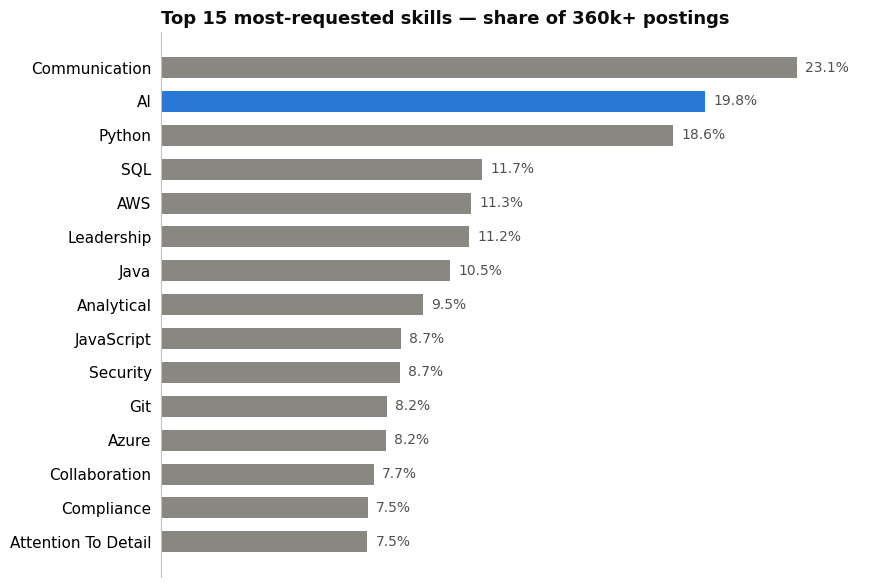

In [2]:
top = overall.head(15).iloc[::-1]   # reversed for horizontal bars
colors = [ACCENT if s == "ai" else NEUTRAL for s in top.skill]

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh([label(s) for s in top.skill], top.pct_of_all_postings,
               color=colors, height=0.62)
for rect, pct in zip(bars, top.pct_of_all_postings):
    ax.text(rect.get_width() + 0.3, rect.get_y() + rect.get_height()/2,
            fmt(pct), va="center", color=INK2, fontsize=10)
ax.set_title("Top 15 most-requested skills — share of 360k+ postings", loc="left",
             fontsize=13, fontweight="bold", color=INK)
ax.set_xlim(0, 26)
ax.spines[["top", "right", "bottom"]].set_visible(False)
ax.tick_params(bottom=False, labelbottom=False, left=False)
plt.tight_layout()
plt.show()

## 2. AI demand peaks at Principal level

AI isn't an entry-level checkbox — demand roughly **doubles at Principal level (39.5%)** versus the overall rate. (The "Not Specified" level is dropped below: n=2.)

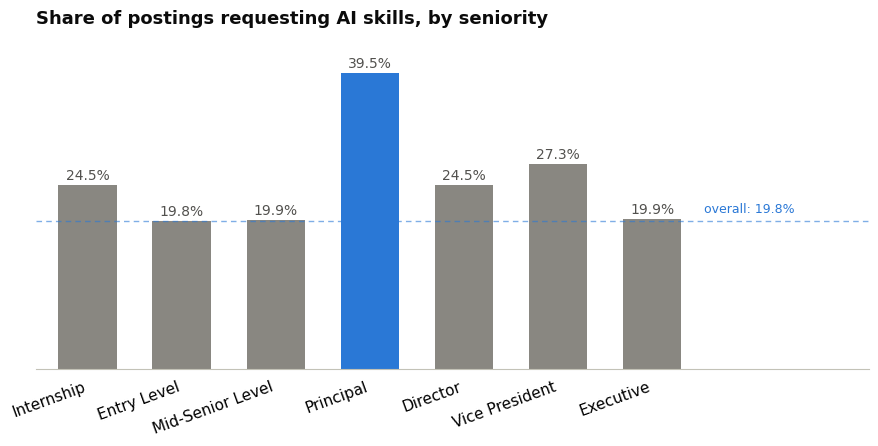

In [3]:
sen = seniority[seniority.seniority != "Not Specified"]
order = ["Internship", "Entry Level", "Mid-Senior Level", "Principal",
         "Director", "Vice President", "Executive"]
sen = sen.set_index("seniority").loc[order].reset_index()
colors = [ACCENT if s == "Principal" else NEUTRAL for s in sen.seniority]

fig, ax = plt.subplots(figsize=(9, 4.6))
bars = ax.bar(sen.seniority, sen.ai_pct_of_level, color=colors, width=0.62)
for rect, pct in zip(bars, sen.ai_pct_of_level):
    ax.text(rect.get_x() + rect.get_width()/2, rect.get_height() + 0.8,
            fmt(pct), ha="center", color=INK2, fontsize=10)
ax.axhline(19.77, color=ACCENT, lw=1, ls=(0, (4, 3)), alpha=0.6)
ax.text(6.55, 20.5, "overall: 19.8%", color=ACCENT, fontsize=9,
        ha="left", va="bottom")
ax.set_title("Share of postings requesting AI skills, by seniority", loc="left",
             fontsize=13, fontweight="bold", color=INK)
ax.set_ylim(0, 45)
ax.set_xlim(-0.55, 8.3)
ax.spines[["top", "right", "left"]].set_visible(False)
ax.tick_params(left=False, labelleft=False, bottom=False)
plt.setp(ax.get_xticklabels(), rotation=20, ha="right")
plt.tight_layout()
plt.show()

## 3. AI is cross-functional — #1 skill for Product Managers

AI is requested across every role family we tracked, and for **Product Managers it's the single most-requested skill (37.0%)** — ahead of any PM tool or methodology. Designers (~23%) and business analysts (~19%) see it too.

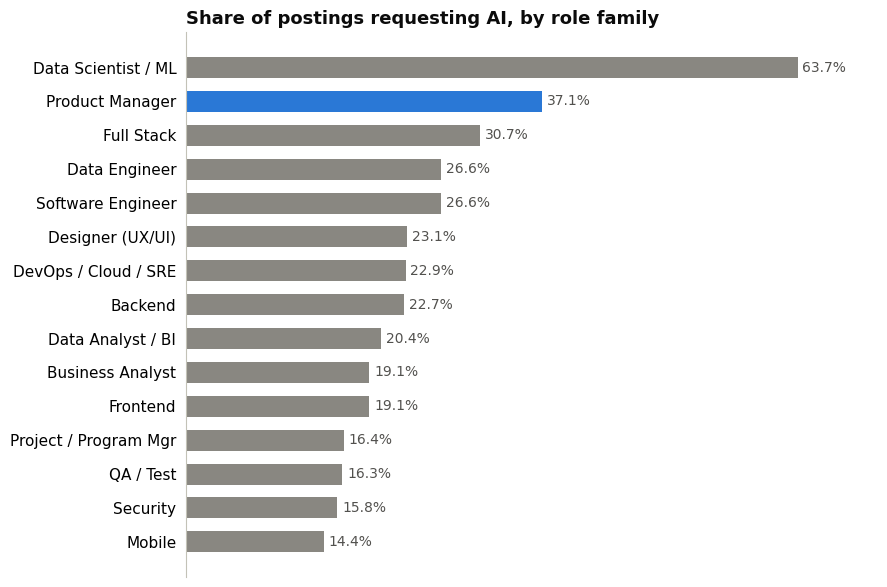

In [4]:
ai_by_role = (by_role[by_role.skill == "ai"]
              .sort_values("pct_of_role")
              .reset_index(drop=True))
colors = [ACCENT if r == "Product Manager" else NEUTRAL for r in ai_by_role.role_family]

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(ai_by_role.role_family, ai_by_role.pct_of_role, color=colors, height=0.62)
for rect, pct in zip(bars, ai_by_role.pct_of_role):
    ax.text(rect.get_width() + 0.5, rect.get_y() + rect.get_height()/2,
            fmt(pct), va="center", color=INK2, fontsize=10)
ax.set_title("Share of postings requesting AI, by role family", loc="left",
             fontsize=13, fontweight="bold", color=INK)
ax.set_xlim(0, 72)
ax.spines[["top", "right", "bottom"]].set_visible(False)
ax.tick_params(bottom=False, labelbottom=False, left=False)
plt.tight_layout()
plt.show()

## Takeaways

- **"AI" is the #2 most-requested skill overall (19.8% of postings)** — behind only communication (23.1%) and ahead of Python (18.6%), SQL (11.7%), AWS (11.3%), and Java (10.5%).
- It's **cross-functional**: #1 skill for Product Managers (37.0%), in ~23% of designer and ~19% of business-analyst postings.
- Demand **peaks at Principal level (39.5%)** — about 2× the overall rate.

Full role-by-role breakdowns, the named AI stack (LLMs, RAG, LangChain…), and remote-vs-onsite cuts are in the [full report](https://www.qarera.com/reports/most-in-demand-skills-2026).

**Citation:** *Qarera analysis of 360,000+ job postings (2026), https://www.qarera.com/reports/most-in-demand-skills-2026. CC BY 4.0.*

*Built by [Qarera](https://www.qarera.com) — a free AI job-search platform (resume builder, ATS checker, job matching, application tracker).*